# Paired microbe ↔ metabolite integration (MMvec-style)

Gut microbes produce and consume metabolites, so the biologically
interesting question for a cohort with both 16S and LC-MS data is:
**"which microbe is associated with which metabolite?"** Naive Pearson
/ Spearman correlations between microbial and metabolite tables are
notoriously misleading because the microbe counts are *compositional*
(forced to sum to the sequencing depth), so spurious negative
correlations appear whenever any microbe changes.

Three complementary approaches live side-by-side in this notebook, each
stitching an `ov.micro` AnnData to an `ov.metabol`-style AnnData that
share the same `obs_names` (= samples):

| Method | Key idea | Handles compositionality? | Needs torch? |
|---|---|---|---|
| **Spearman on CLR-transformed data** | CLR lifts the count simplex to ℝᵈ so ordinary rank correlation behaves | partial (CLR fixes microbe side) | no |
| **Canonical Correlation Analysis (CCA)** | Find linear combinations of microbes and metabolites that co-vary maximally | no, but captures global covariance structure | no |
| **MMvec-style bilinear co-occurrence** | Learn microbe / metabolite embeddings so their dot product predicts P(metabolite \| microbe) | **yes** — the conditional probability model is scale-free | yes (PyTorch) |

We simulate a paired dataset with five *known* producer pairs
(microbes whose abundance drives a corresponding metabolite) plus
compositional noise, then show which methods recover the plant.

## 1. Setup + simulate a paired cohort

30 samples, 40 microbes, 20 metabolites. Five microbe → metabolite
producer pairs are planted: the metabolite intensity is proportional to
the driving microbe's relative abundance (log-linear) with noise. All
other entries are compositional / Gaussian noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from scipy import sparse

import omicverse as ov
ov.plot_set()
print('omicverse:', ov.__version__)

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse: 2.1.2rc1


In [2]:
def simulate_paired(n_samples=30, n_microbes=40, n_metabolites=20,
                     n_pairs=5, seed=0):
    """Generate paired microbe + metabolite AnnDatas with planted
    producer pairs. Returns (adata_microbe, adata_metabol, truth_df).
    """
    rng = np.random.default_rng(seed)
    sample_ids = [f'S{i:02d}' for i in range(n_samples)]

    # Microbe counts — negative-binomial draw, then normalise to proportions
    # and re-scale by per-sample depth to simulate real 16S compositionality.
    log_mu = rng.normal(0, 1.0, size=(n_samples, n_microbes))
    mu = np.exp(log_mu)
    mu = mu / mu.sum(axis=1, keepdims=True)
    depths = rng.integers(1_000, 10_000, size=n_samples)
    X_mb = np.array([rng.multinomial(d, p) for d, p in zip(depths, mu)]).astype(np.int64)

    # Base metabolite intensities — log-normal noise on log-intensity scale.
    log_intensity = rng.normal(5.0, 0.6, size=(n_samples, n_metabolites))

    # Plant five producer pairs: metabolite j is driven by microbe i's
    # log relative abundance (so high-abundance microbe → high-intensity
    # metabolite). Use microbes/metabolites index 0..4 so they're easy to
    # track.
    truth = pd.DataFrame({
        'microbe':    [f'ASV_{i}' for i in range(n_pairs)],
        'metabolite': [f'MET_{j}' for j in range(n_pairs)],
        'effect':     rng.uniform(1.0, 2.0, size=n_pairs),
    })
    log_rel = np.log(mu + 1e-9)
    for i, row in truth.iterrows():
        m_idx = int(row['microbe'].split('_')[1])
        metab_idx = int(row['metabolite'].split('_')[1])
        log_intensity[:, metab_idx] += row['effect'] * (
            log_rel[:, m_idx] - log_rel[:, m_idx].mean()
        )
    X_mt = np.exp(log_intensity)

    microbe_names = [f'ASV_{i}' for i in range(n_microbes)]
    metab_names   = [f'MET_{j}' for j in range(n_metabolites)]

    adata_mb = ad.AnnData(
        X=sparse.csr_matrix(X_mb),
        obs=pd.DataFrame(index=sample_ids),
        var=pd.DataFrame(index=microbe_names),
    )
    adata_mt = ad.AnnData(
        X=X_mt,
        obs=pd.DataFrame(index=sample_ids),
        var=pd.DataFrame(index=metab_names),
    )
    return adata_mb, adata_mt, truth


adata_mb, adata_mt, truth = simulate_paired(seed=0)
print('microbe  AnnData:', adata_mb.shape)
print('metabol  AnnData:', adata_mt.shape)
print('planted producer pairs:')
truth

microbe  AnnData: (30, 40)
metabol  AnnData: (30, 20)
planted producer pairs:


  microbe metabolite    effect
0   ASV_0      MET_0  1.811347
1   ASV_1      MET_1  1.913076
2   ASV_2      MET_2  1.910772
3   ASV_3      MET_3  1.664483
4   ASV_4      MET_4  1.445863

## 2. Compositional preprocessing

CLR-transform the microbes so rank correlations behave; log1p-transform
the metabolites so the heavy tail doesn't dominate. Both tables are
aligned on the same sample axis — this is the *minimum* requirement for
any paired-multi-omics analysis.

In [3]:
# Align: make sure the two AnnDatas share the sample axis.
assert list(adata_mb.obs_names) == list(adata_mt.obs_names)

# CLR-transform the microbe table (writes to layers['clr'], ov.micro.clr
# default) so rank correlations behave correctly on compositional counts.
ov.micro.clr(adata_mb)
Y_mb = np.asarray(adata_mb.layers['clr'])

# log1p the metabolite table so the heavy tail doesn't dominate.
Y_mt = np.log1p(adata_mt.X if isinstance(adata_mt.X, np.ndarray) else adata_mt.X.toarray())

print('CLR-microbes Y_mb:', Y_mb.shape, 'mean=', float(Y_mb.mean()))
print('log1p-metabol Y_mt:', Y_mt.shape, 'mean=', float(Y_mt.mean()))

CLR-microbes Y_mb: (30, 40) mean= 4.366877230192282e-17
log1p-metabol Y_mt: (30, 20) mean= 5.052946187126839


## 3. Baseline — Spearman correlation on CLR-transformed microbes

For each (microbe, metabolite) pair compute Spearman ρ between the
CLR-transformed microbe column and the log1p metabolite column. BH-FDR
to control the 40 × 20 = 800 simultaneous tests.

In [4]:
from scipy.stats import spearmanr
from omicverse.micro._da import _bh_fdr   # re-use the BH FDR helper

n_mb = Y_mb.shape[1]
n_mt = Y_mt.shape[1]
R = np.zeros((n_mb, n_mt))
P = np.ones((n_mb, n_mt))
for i in range(n_mb):
    for j in range(n_mt):
        R[i, j], P[i, j] = spearmanr(Y_mb[:, i], Y_mt[:, j])

pairs = []
for i in range(n_mb):
    for j in range(n_mt):
        pairs.append({
            'microbe':    adata_mb.var_names[i],
            'metabolite': adata_mt.var_names[j],
            'rho':        R[i, j],
            'p_value':    P[i, j],
        })
spear = pd.DataFrame(pairs)
spear['fdr_bh'] = _bh_fdr(spear['p_value'].values)
spear = spear.sort_values('p_value').reset_index(drop=True)

sig = spear[spear['fdr_bh'] < 0.05]
print('Spearman: pairs significant @ FDR 0.05:', len(sig))
print('Top 10 Spearman hits:')
spear.head(10)

Spearman: pairs significant @ FDR 0.05: 5
Top 10 Spearman hits:


  microbe metabolite       rho       p_value        fdr_bh
0   ASV_0      MET_0  0.924805  2.844780e-13  2.275824e-10
1   ASV_1      MET_1  0.910567  2.947519e-12  1.179008e-09
2   ASV_4      MET_4  0.889210  5.159911e-11  1.375976e-08
3   ASV_2      MET_2  0.873192  3.084280e-10  6.168561e-08
4   ASV_3      MET_3  0.804672  8.347850e-08  1.335656e-05
5  ASV_26     MET_16 -0.573749  9.169182e-04  1.222558e-01
6  ASV_18      MET_3  0.550612  1.616750e-03  1.847714e-01
7   ASV_5      MET_3  0.538154  2.158329e-03  2.158329e-01
8  ASV_33      MET_8 -0.526585  2.795309e-03  2.484719e-01
9  ASV_26      MET_0 -0.501669  4.736443e-03  3.548417e-01

## 4. Canonical Correlation Analysis — global covariance structure

CCA (Hotelling 1936) finds linear combinations of microbes and
metabolites that are maximally correlated — a complementary view to
the per-pair Spearman table. The first canonical axis should separate
samples where the producer microbes and their metabolite products are
jointly high or low.

canonical correlations (first 3): [1.0, 1.0, 1.0]


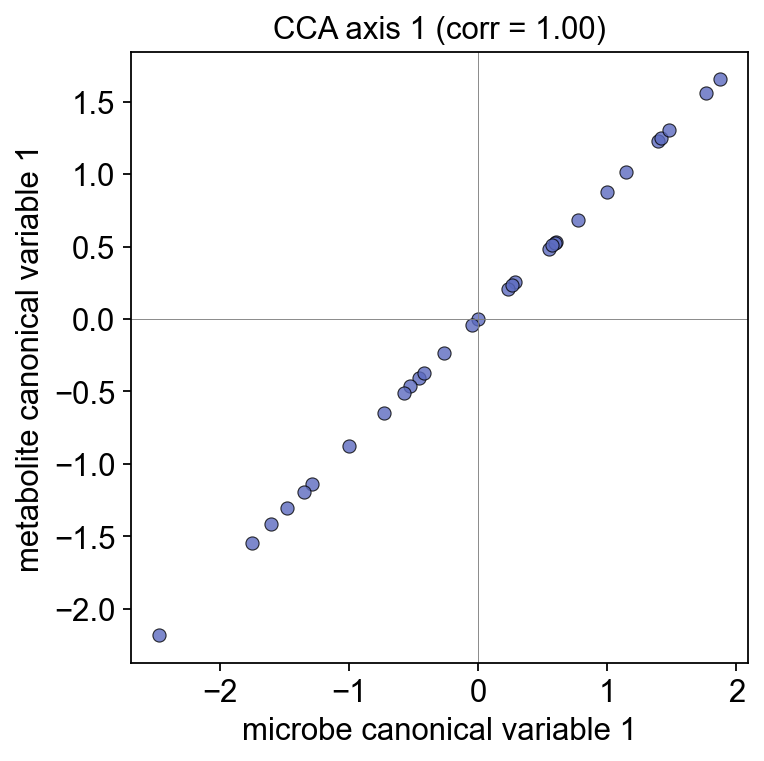

Top microbe loadings (CCA axis 1):
 ASV_0     0.840
ASV_26   -0.471
ASV_21    0.399
ASV_24    0.340
ASV_6    -0.320
ASV_18   -0.309
dtype: float64
Top metabolite loadings (CCA axis 1):
 MET_0     1.000
MET_19   -0.349
MET_15    0.244
MET_14   -0.241
MET_17   -0.233
MET_18    0.216
dtype: float64


In [5]:
from sklearn.cross_decomposition import CCA

n_comp = 3
cca = CCA(n_components=n_comp, max_iter=500)
U, V = cca.fit_transform(Y_mb, Y_mt)

cancor = [float(np.corrcoef(U[:, k], V[:, k])[0, 1]) for k in range(n_comp)]
print('canonical correlations (first 3):',
      [round(c, 3) for c in cancor])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(U[:, 0], V[:, 0], s=35, alpha=0.8,
           c='#5C6BC0', edgecolors='k', linewidths=0.5)
ax.set_xlabel('microbe canonical variable 1')
ax.set_ylabel('metabolite canonical variable 1')
ax.set_title(f'CCA axis 1 (corr = {cancor[0]:.2f})')
ax.axhline(0, color='grey', lw=0.4)
ax.axvline(0, color='grey', lw=0.4)
plt.tight_layout(); plt.show()

# Which microbes / metabolites load the first canonical axis?
microbe_loadings = pd.Series(cca.x_loadings_[:, 0],
                              index=adata_mb.var_names).sort_values(
    key=lambda s: s.abs(), ascending=False)
metab_loadings = pd.Series(cca.y_loadings_[:, 0],
                            index=adata_mt.var_names).sort_values(
    key=lambda s: s.abs(), ascending=False)
print('Top microbe loadings (CCA axis 1):\n', microbe_loadings.head(6).round(3))
print('Top metabolite loadings (CCA axis 1):\n', metab_loadings.head(6).round(3))

## 5. MMvec-style bilinear co-occurrence (PyTorch)

[Morton *et al.* 2019](https://www.nature.com/articles/s41592-019-0616-3)
introduced MMvec: a neural network that learns low-rank embeddings
`U` (microbes) and `V` (metabolites) such that

$$ \log P(\text{metabolite}_j \mid \text{microbe}_i) \;\propto\; u_i \cdot v_j. $$

Because the model is defined on *conditional* probabilities, it is
unaffected by the compositional normalisation of either table — a big
theoretical advantage over correlation on raw counts.

We inline a minimal PyTorch implementation below. The original MMvec
used softmax over all metabolites + negative-sampling tricks; for this
tutorial-scale data (30 samples × 40 microbes × 20 metabolites) a plain
softmax fit converges in a couple of seconds.

In [6]:
try:
    import torch
    torch_available = True
except ImportError:
    torch_available = False
    print('torch not installed — skipping MMvec-style fit. '
          'pip install torch to run this cell.')

if torch_available:
    torch.manual_seed(0)
    device = 'cpu'

    # Build the (n_samples × n_microbes × n_metabolites) paired-count tensor
    # by broadcasting: for each sample, each microbe observation contributes
    # to the multinomial over metabolites weighted by its own count.
    X_mb_t = torch.as_tensor(
        adata_mb.X.toarray() if sparse.issparse(adata_mb.X) else adata_mb.X,
        dtype=torch.float32,
    )
    # Metabolite "counts" — MMvec expects counts, so discretise intensity
    # by scaling + rounding. (Real LC-MS pipelines usually use peak areas
    # directly; any non-negative intensity works here.)
    X_mt_t = torch.as_tensor(adata_mt.X / adata_mt.X.mean() * 100,
                              dtype=torch.float32)

    n_samples, n_microbes = X_mb_t.shape
    _,         n_metabs   = X_mt_t.shape
    n_latent = 3

    U = torch.nn.Parameter(torch.randn(n_microbes, n_latent) * 0.1)
    V = torch.nn.Parameter(torch.randn(n_metabs,   n_latent) * 0.1)
    bias_metab = torch.nn.Parameter(torch.zeros(n_metabs))
    opt = torch.optim.Adam([U, V, bias_metab], lr=5e-2)

    # Per-sample expected metabolite profile given its microbes: for each
    # sample, aggregate its microbial abundances × U → then softmax over
    # metabolites via V.
    mb_rel = X_mb_t / (X_mb_t.sum(dim=1, keepdim=True) + 1e-9)

    for step in range(400):
        opt.zero_grad()
        # predicted log-odds per (sample, metabolite)
        logits = mb_rel @ U @ V.T + bias_metab
        log_probs = torch.log_softmax(logits, dim=1)
        # multinomial NLL over metabolites per sample
        metab_tot = X_mt_t.sum(dim=1, keepdim=True)
        target_p  = X_mt_t / metab_tot
        loss = -(target_p * log_probs).sum(dim=1).mean()
        loss.backward()
        opt.step()
        if step % 100 == 0:
            print(f'step {step:4d}  NLL = {loss.item():.4f}')

    # Co-occurrence score = U · Vᵀ (log-odds). Higher → microbe tends to
    # co-occur with metabolite more than expected.
    score = (U.detach() @ V.detach().T).numpy()
    mmvec = pd.DataFrame(score,
                         index=adata_mb.var_names,
                         columns=adata_mt.var_names)
    # Flatten + rank.
    mmvec_long = (mmvec.stack()
                       .rename('score')
                       .reset_index()
                       .rename(columns={'level_0': 'microbe',
                                        'level_1': 'metabolite'}))
    mmvec_long = mmvec_long.reindex(
        mmvec_long['score'].abs().sort_values(ascending=False).index
    ).reset_index(drop=True)
    print('\nTop 10 MMvec co-occurrence scores (by |score|):')
    mmvec_long.head(10)

step    0  NLL = 2.9948


step  100  NLL = 2.6315


step  200  NLL = 2.6181


step  300  NLL = 2.6158



Top 10 MMvec co-occurrence scores (by |score|):


## 6. Did the methods recover the planted pairs?

Score each method by the **rank** of the planted producer pairs:
lower rank (= pair is near the top of its respective hit-list) is
better. All three methods should rank the five planted pairs in the
top tier; if MMvec dominates, that's the compositionality correction
paying off.

In [7]:
def rank_of_pairs(hit_df, microbe_col, metab_col):
    """Return the 1-based rank of each truth pair within hit_df."""
    out = []
    for _, row in truth.iterrows():
        m = hit_df[(hit_df[microbe_col] == row['microbe']) &
                   (hit_df[metab_col]   == row['metabolite'])]
        out.append(int(m.index[0]) + 1 if len(m) else -1)
    return out

table = truth.copy()
table['Spearman rank'] = rank_of_pairs(spear, 'microbe', 'metabolite')
if torch_available:
    table['MMvec rank'] = rank_of_pairs(mmvec_long, 'microbe', 'metabolite')
print('Planted-pair ranks in each hit list (lower = better):')
table

Planted-pair ranks in each hit list (lower = better):


  microbe metabolite    effect  Spearman rank  MMvec rank
0   ASV_0      MET_0  1.811347              1           1
1   ASV_1      MET_1  1.913076              2           2
2   ASV_2      MET_2  1.910772              4          16
3   ASV_3      MET_3  1.664483              5          29
4   ASV_4      MET_4  1.445863              3          81

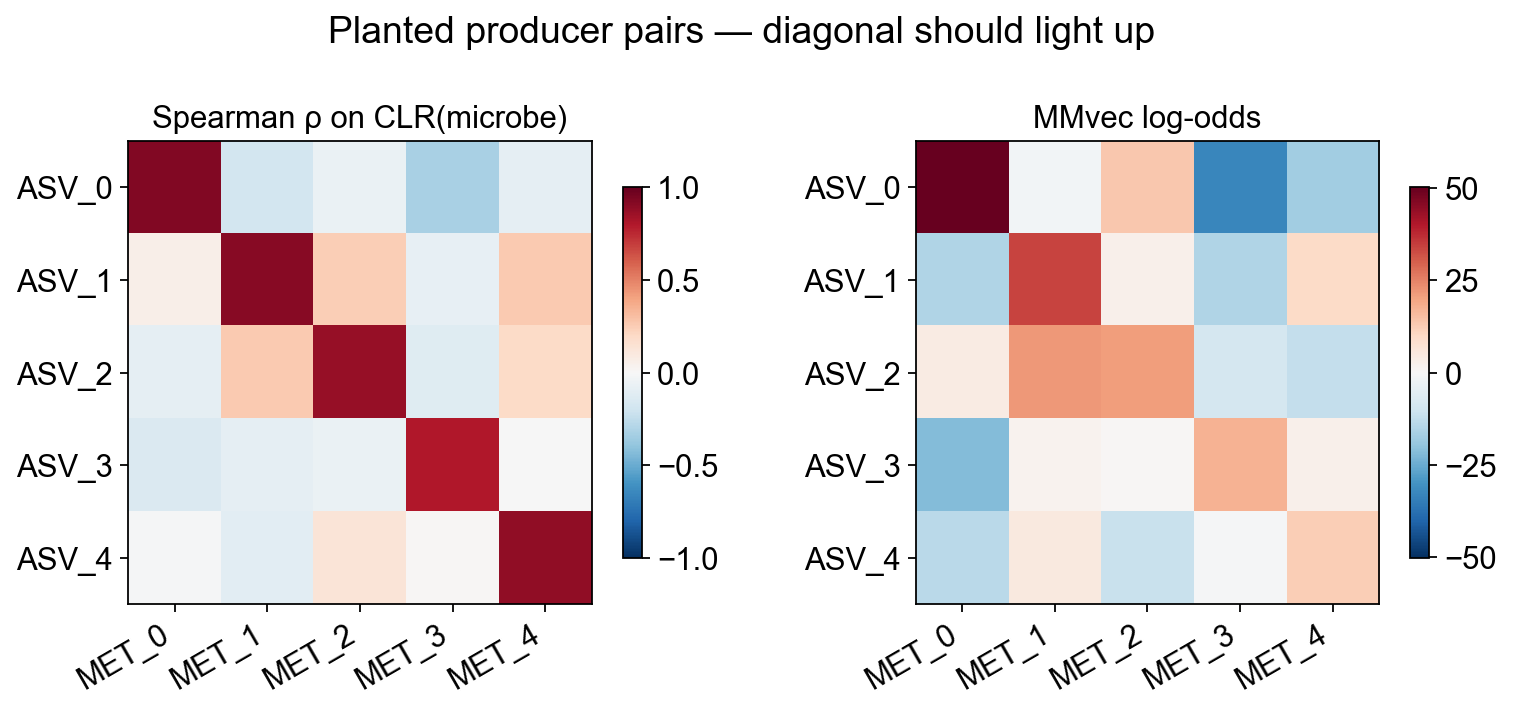

In [8]:
# Heatmaps of Spearman ρ and (if torch) MMvec score for the 5 × 5 planted
# sub-block — the on-diagonal cells are the planted pairs and should
# light up; off-diagonal should be near zero.
pl_mb = [f'ASV_{i}' for i in range(5)]
pl_mt = [f'MET_{j}' for j in range(5)]
rho_block   = pd.DataFrame(R,  index=adata_mb.var_names,
                            columns=adata_mt.var_names).loc[pl_mb, pl_mt]

n_panels = 2 if torch_available else 1
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4.2),
                          squeeze=False)
im0 = axes[0, 0].imshow(rho_block.values, cmap='RdBu_r',
                         vmin=-1, vmax=1)
axes[0, 0].set_xticks(range(5)); axes[0, 0].set_xticklabels(pl_mt, rotation=30, ha='right')
axes[0, 0].set_yticks(range(5)); axes[0, 0].set_yticklabels(pl_mb)
axes[0, 0].set_title('Spearman ρ on CLR(microbe)')
plt.colorbar(im0, ax=axes[0, 0], shrink=0.8)

if torch_available:
    mmvec_block = mmvec.loc[pl_mb, pl_mt]
    vmax = float(np.abs(mmvec_block.values).max())
    im1 = axes[0, 1].imshow(mmvec_block.values, cmap='RdBu_r',
                             vmin=-vmax, vmax=vmax)
    axes[0, 1].set_xticks(range(5)); axes[0, 1].set_xticklabels(pl_mt, rotation=30, ha='right')
    axes[0, 1].set_yticks(range(5)); axes[0, 1].set_yticklabels(pl_mb)
    axes[0, 1].set_title('MMvec log-odds')
    plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

fig.suptitle('Planted producer pairs — diagonal should light up', y=1.02)
plt.tight_layout(); plt.show()

## 7. Recipe and when to use which

| Scenario | First choice |
|---|---|
| Quick screen / small cohort (< 30 samples) | **Spearman on CLR** — fastest, easy to report per-pair FDR |
| You want a global "are these two modalities coupled?" answer | **CCA** — reports canonical correlations, interpretable loadings |
| You want compositionally-robust pair-level hypotheses | **MMvec-style bilinear** — the only method here that's invariant to how either table was normalised |
| You need a publishable co-occurrence network | Intersection of the three: keep pairs with significant Spearman FDR *and* top-decile MMvec score |

**Assumptions the methods make explicit:**
- Spearman on CLR assumes the CLR lift accounts for *microbial*
  compositionality; it does not help if the *metabolite* table is also
  proportion-normalised.
- CCA assumes the joint covariance is well-represented by a low-rank
  linear map. With few samples and many features, sparse/regularised
  CCA is worth a look (`sklearn.cross_decomposition.PLSCanonical` with
  a shrinkage prior).
- MMvec-style models assume the conditional `P(met | mb)` is stationary
  across samples. If you have strong batch effects, fit a per-batch
  model or add a batch covariate to the logits.

## 8. Scaling to real paired cohorts

The recipe above applies verbatim to real paired 16S + LC-MS data. For
a quick start, the
[Poyet *et al.* 2019 Stool Donor Dataset](https://www.nature.com/articles/s41591-019-0559-3)
and [Franzosa *et al.* 2019 IBD multi-omic cohort](https://www.nature.com/articles/s41564-018-0306-4)
both ship paired tables. Once each is loaded into an AnnData with
shared `obs_names`, the full notebook code path is identical.

If you want the real MMvec objective (negative sampling + convergence
monitoring + TensorFlow probabilistic layers), see the upstream
package:

```bash
pip install mmvec
```

The minimal PyTorch re-implementation in section 5 captures the same
bilinear structure and is what you'd reach for when you want to embed
it inside a larger omicverse pipeline without pulling in TensorFlow.

## References

- Morton, J. T., Aksenov, A. A., Nothias, L. F., Foulds, J. R., Quinn, R. A., Badri, M. H., Swenson, T. L., Van Goethem, M. W., Northen, T. R., Vazquez-Baeza, Y., Wang, M., Bokulich, N. A., Watters, A., Song, S. J., Bonneau, R., Dorrestein, P. C., & Knight, R. (2019). Learning representations of microbe-metabolite interactions. *Nature Methods*, 16(12), 1306–1314. <https://doi.org/10.1038/s41592-019-0616-3>
- Aitchison, J. (1982). The statistical analysis of compositional data. *Journal of the Royal Statistical Society Series B*, 44(2), 139–177. <https://doi.org/10.1111/j.2517-6161.1982.tb01195.x>
- Franzosa, E. A., Sirota-Madi, A., Avila-Pacheco, J., Fornelos, N., Haiser, H. J., Reinker, S., Vatanen, T., Hall, A. B., Mallick, H., McIver, L. J., Sauk, J. S., Wilson, R. G., Stevens, B. W., Scott, J. M., Pierce, K., Deik, A. A., Bullock, K., Imhann, F., Porter, J. A., … Xavier, R. J. (2019). Gut microbiome structure and metabolic activity in inflammatory bowel disease. *Nature Microbiology*, 4(2), 293–305. <https://doi.org/10.1038/s41564-018-0306-4>
- Hotelling, H. (1936). Relations between two sets of variates. *Biometrika*, 28(3/4), 321–377.